In [2]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_mask_distributions, plot_metric_vs_lambda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

## Set up

In [4]:
switch = load_results_from_pickle(folder='ICML_experiments/synthetic',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig']
                                        )

temp = switch.copy()
temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp = temp.query('syn != "Syn7"')

In [5]:
assert (temp.query('model!="LASSO"').num_syn_features == 11).all()

# Partition analysis boxplots

In [6]:
def find_switch_accuracy(row):
    switch_accuracy = (row['binary_mask'][:,-1] == row['g_test'][:,-1]).mean()
    return switch_accuracy

In [7]:
temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)
temp['syn'] = temp.syn.str[-1].astype(int)
# temp['model'] = temp['model'].replace(rename_dict)
cols_to_num = ['TPR_mean', 'FDR_mean', 'f1', 'switch_accuracy', 'seed', 'lmbda']

for col in cols_to_num:
    temp[col] = pd.to_numeric(temp[col])

In [8]:
cols = ['model', 'syn', 'TPR_mean', 'FDR_mean', 'switch_accuracy', 'run_type', 'F1', 'seed', 'lmbda']
switch_metrics = temp[cols].copy()
switch_metrics = switch_metrics.sort_values(by=['model','syn']).reset_index(drop=True)

In [9]:
assert (switch_metrics.drop('lmbda',axis=1).groupby(['model','syn']).count() == 20).all(axis=1).all()

In [10]:
switch_metrics.groupby(['model','syn']).count()

TPR_mean  FDR_mean  switch_accuracy  run_type  F1  seed  lmbda
model     syn                                                                
Hide&Seek 1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
INVASE    1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
L2X       1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
LASSO     1          20        20               20        20  20    20      0
          2          20        20               20        20  20    20      0
          3          20        20               20        20  20    20      0
          4          20        20               20        20  20    20      0
          5          20        20               20        20  20    20      0
          6          20        20               20        20  20    20      0
LIME      1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
REAL-x    1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
RForest   1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
SHAP      1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20

-- switch analysis -- 

Note - an interesting conversation comes around whether to scale or not when the data is drawn from N(0,1). Even when sampled from this population, there will be some variance in means for train and test. To reflect true production pipelines, where we don't know the distrubtion of test, we chose to normalize to the train set. In doing so, switch-feature leakage from invase (some) and l2x (all) decreased.

In [57]:
def make_last_column_one(bin_mask):
    bin_mask_comp = bin_mask.copy()
    bin_mask_comp[:,-1]=1
    return bin_mask_comp

what is the impact if INVASE were to get the switch feature?

In [58]:
invase = temp.query('model=="INVASE" & syn>3')[['syn','binary_mask','g_test']].copy()
bin_mask = invase['binary_mask'].iloc[0]
invase['binary_mask_adjusted'] = invase['binary_mask'].apply(lambda bin_mask: make_last_column_one(bin_mask))
invase[['TPR','FDR','F1']] = invase.apply(
    compute_rowwise_metrics,
    axis=1,
    just_f1=False,
    bin_mask_column='binary_mask_adjusted'
)
invase.groupby('syn')['TPR'].median()

syn
4    0.998513
5    0.997980
6    0.998690
Name: TPR, dtype: float64

-- switch analysis end --

In [11]:
colys = ['syn','lmbda','epochs']
temp.query('model=="INVASE"')[colys].value_counts()

syn  lmbda  epochs
1    0.1    10000     20
2    0.1    10000     20
3    0.1    10000     20
4    0.1    10000     20
5    0.1    10000     20
6    0.1    10000     20
dtype: int64

In [12]:
results456 = switch_metrics.query('syn>3')
results456.groupby(['model','syn'])['switch_accuracy'].median()

model      syn
Hide&Seek  4      1.00000
           5      1.00000
           6      0.99955
INVASE     4      0.52025
           5      0.50285
           6      0.51110
L2X        4      0.57905
           5      0.57685
           6      0.57575
LASSO      4      1.00000
           5      1.00000
           6      1.00000
LIME       4      0.32560
           5      0.23005
           6      0.00065
REAL-x     4      1.00000
           5      1.00000
           6      1.00000
RForest    4      1.00000
           5      1.00000
           6      1.00000
SHAP       4      0.88060
           5      0.87940
           6      0.70595
Name: switch_accuracy, dtype: float64

In [13]:
results456['syn'] = results456['syn'].apply(lambda x: f'Syn{x}')

/tmp/ipykernel_1715315/118160301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results456['syn'] = results456['syn'].apply(lambda x: f'Syn{x}')


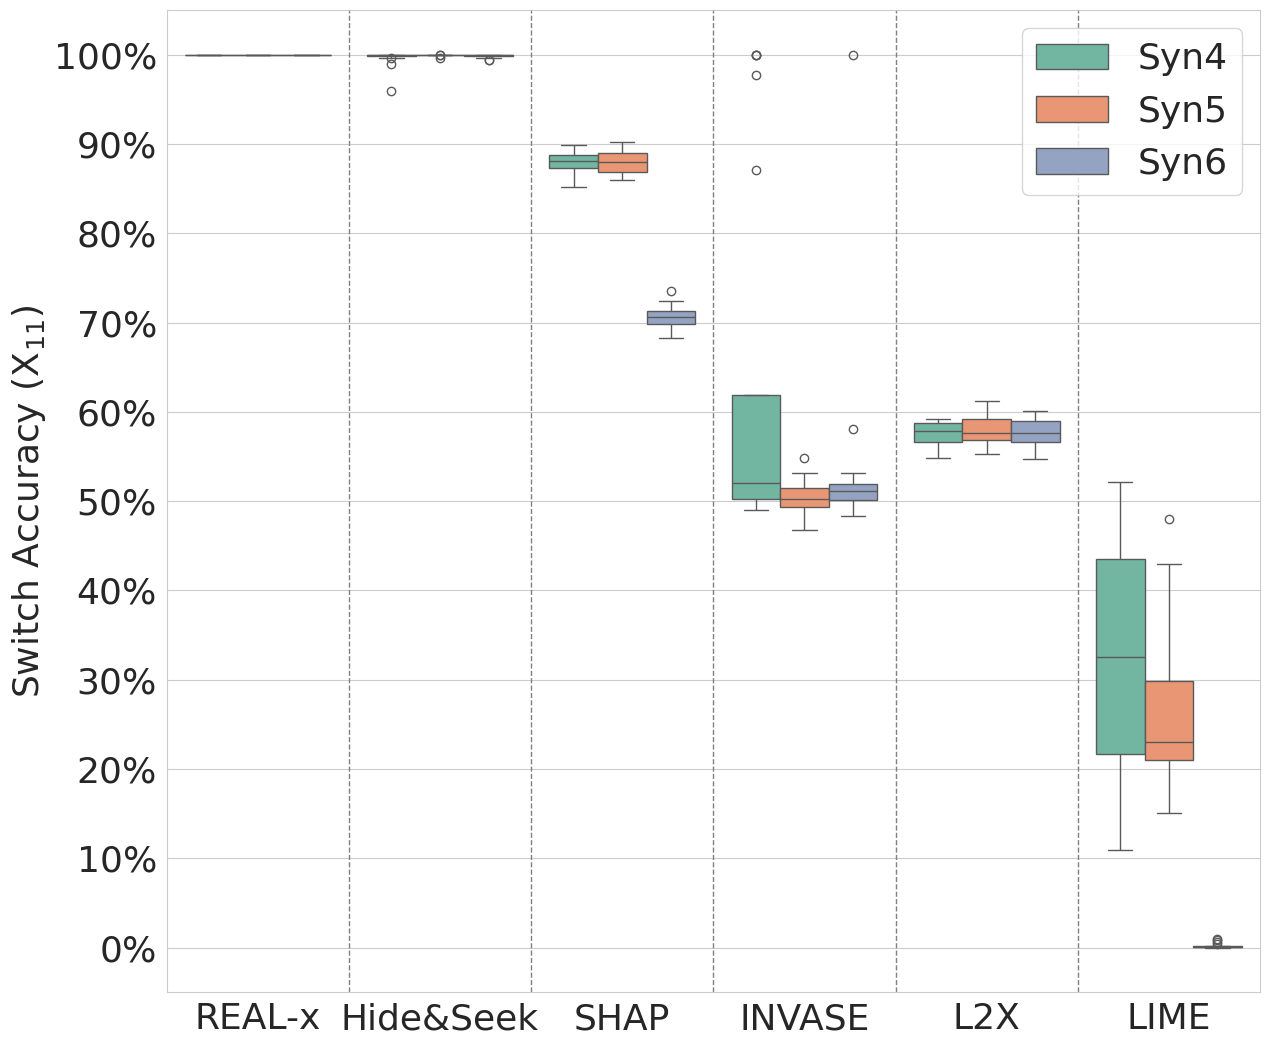

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter
import matplotlib.ticker as mticker

save_path = os.path.join(os.path.abspath('..'), 'figures', 'switch_accuracy_boxplots.pdf') 
save_path = os.path.expanduser(save_path)

rename_dict = {
    'hide_and_seek': 'Hide&Seek',
    'l2x': 'L2X',
    'lime': 'LIME',
    'invase': 'INVASE',
    'shap_xgboost':'SHAP',
    'lasso':"LASSO",
    'random_forest':"RForest",
    'realx':'REAL-x'
}

# Drop unwanted models
models_to_drop = ['RForest','LASSO']
results456 = results456[~results456['model'].isin(models_to_drop)].copy()
results456['model'] = results456['model'].replace(rename_dict)

# Multiply switch_accuracy by 100 for plotting
results456['switch_accuracy_pct'] = results456['switch_accuracy'] * 100

# ---------------------------------------------------------------------
# Set global font to Computer Modern serif
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
# ---------------------------------------------------------------------

fontsize_labels = 26  # axis titles
fontsize_ticks = 26  # tick labels

syn_levels = sorted(results456['syn'].unique())
sns.set_style("whitegrid")
custom_palette = sns.color_palette("Set2", n_colors=len(syn_levels))
model_order = ['REAL-x', 'Hide&Seek', 'SHAP', 'INVASE', 'L2X', 'LIME']

fig, ax = plt.subplots(figsize=(12.8, 9.6*1.1))

sns.boxplot(
    data=results456,
    x='model',
    y='switch_accuracy_pct',
    hue='syn',
    order=model_order,
    palette=custom_palette,
    ax=ax
)

# --- Axis labels & ticks
ax.set_xlabel('', fontsize=fontsize_labels)
ax.set_ylabel(r'Switch Accuracy (X$_{11}$)', fontsize=fontsize_labels)
ax.tick_params(axis='x', labelsize=fontsize_ticks)
ax.tick_params(axis='y', labelsize=fontsize_ticks)
# ax.set_ylim(99.999,100)
# Format y-axis as percentages
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(PercentFormatter())


# Optional: add vertical lines between models
for i in range(len(model_order) - 1):
    ax.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=1)

# --- Legend
ax.legend(fontsize=fontsize_ticks, title_fontsize=fontsize_ticks)

fig.tight_layout()
plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()


In [16]:
outlier_dict = {}

for model in model_order:
    df_model = results456[results456['model'] == model]
    outlier_dict[model] = {}  # initialize inner dict for each syn
    
    for syn in df_model['syn'].unique():
        df_group = df_model[df_model['syn'] == syn]
        Q1 = df_group['switch_accuracy'].quantile(0.25)
        Q3 = df_group['switch_accuracy'].quantile(0.75)
        IQR = Q3 - Q1
        
        is_outlier = (df_group['switch_accuracy'] < Q1 - 1.5*IQR) | (df_group['switch_accuracy'] > Q3 + 1.5*IQR)
        outliers = df_group[is_outlier][['seed', 'switch_accuracy']]
        
        # save as list of dictionaries with 'seed' and 'acc'
        outlier_dict[model][f'Syn{syn}'] = [
            {'seed': seed, 'acc': acc} for seed, acc in outliers.values
        ]


In [17]:
outlier_dict

{'REAL-x': {'SynSyn4': [], 'SynSyn5': [], 'SynSyn6': []},
 'Hide&Seek': {'SynSyn4': [{'seed': 5.0, 'acc': 0.9595},
   {'seed': 7.0, 'acc': 0.9891},
   {'seed': 10.0, 'acc': 0.9957}],
  'SynSyn5': [{'seed': 0.0, 'acc': 0.9958},
   {'seed': 2.0, 'acc': 0.9992},
   {'seed': 6.0, 'acc': 0.9991}],
  'SynSyn6': [{'seed': 2.0, 'acc': 0.9944}, {'seed': 11.0, 'acc': 0.9938}]},
 'SHAP': {'SynSyn4': [],
  'SynSyn5': [],
  'SynSyn6': [{'seed': 14.0, 'acc': 0.7358}]},
 'INVASE': {'SynSyn4': [{'seed': 1.0, 'acc': 1.0},
   {'seed': 4.0, 'acc': 0.9767},
   {'seed': 7.0, 'acc': 1.0},
   {'seed': 20.0, 'acc': 0.8707},
   {'seed': 9.0, 'acc': 1.0}],
  'SynSyn5': [{'seed': 10.0, 'acc': 0.5481}],
  'SynSyn6': [{'seed': 1.0, 'acc': 1.0}, {'seed': 14.0, 'acc': 0.581}]},
 'L2X': {'SynSyn4': [], 'SynSyn5': [], 'SynSyn6': []},
 'LIME': {'SynSyn4': [],
  'SynSyn5': [{'seed': 3.0, 'acc': 0.48}],
  'SynSyn6': [{'seed': 8.0, 'acc': 0.0102},
   {'seed': 9.0, 'acc': 0.0043},
   {'seed': 10.0, 'acc': 0.0062},
   {'see

## Median values

In [18]:
independent_medians = switch_metrics.groupby(['model','syn'])[['TPR_mean', 'FDR_mean']].median().reset_index()


In [19]:
# --- start from your medians df ---
df = independent_medians.copy()
df['model'] = df['model'].replace(rename_dict)
df["syn"] = df["syn"].astype(int)

# Round values
df["TPR"] = df["TPR_mean"].round().astype(int)
df["FDR"] = df["FDR_mean"].round().astype(int)

# New model order (matches your NEW TABLE)
model_order = ["Hide&Seek", "INVASE", "REAL-x", "SHAP", "LIME", "L2X", "RForest", "LASSO"]

# Pivot so rows are syn and columns are model (new format)
pivot_tpr = df.pivot(index="syn", columns="model", values="TPR").reindex(columns=model_order)
pivot_fdr = df.pivot(index="syn", columns="model", values="FDR").reindex(columns=model_order)

# Per-syn bests for bolding
max_tpr_per_syn = pivot_tpr.max(axis=1, skipna=True)
min_fdr_per_syn = pivot_fdr.min(axis=1, skipna=True)

def latex_escape_model(name: str) -> str:
    return name.replace("&", r"\&")

# ----- Header (tabular only, as in your NEW TABLE) -----
colspec = "l|" + "|".join(["cc"] * (len(model_order) - 1)) + "|cc"  # last group no trailing |
header1 = (
    r"\text{Model} "
    + "\n& " + "\n& ".join([rf"\multicolumn{{2}}{{c{'|' if i < len(model_order)-1 else ''}}}{{{latex_escape_model(m)}}}"
                           for i, m in enumerate(model_order)])
    + r" \\"
)

header2 = (
    r"% \text{Metrics}"
    + "\n& " + " & ".join(["TPR & FDR"] * len(model_order))
    + r" \\"
)

latex_rows = []
for syn in range(1, 7):
    row = [f"Syn{syn}"]
    for m in model_order:
        tpr = pivot_tpr.loc[syn, m]
        fdr = pivot_fdr.loc[syn, m]

        # Handle missing gracefully
        if pd.isna(tpr):
            tpr_str = "--"
        else:
            tpr = int(tpr)
            tpr_str = rf"\textbf{{{tpr}}}" if tpr == max_tpr_per_syn.loc[syn] else f"{tpr}"

        if pd.isna(fdr):
            fdr_str = "--"
        else:
            fdr = int(fdr)
            fdr_str = rf"\textbf{{{fdr}}}" if fdr == min_fdr_per_syn.loc[syn] else f"{fdr}"

        row.extend([tpr_str, fdr_str])

    latex_rows.append(" & ".join(row) + r" \\")

latex_table = "\n".join([
    rf"\begin{{tabular}}{{{colspec}}}",
    r"\hline",
    header1,
    header2,
    r"\hline",
    *latex_rows,
    r"\hline",
    r"\end{tabular}",
])

print(latex_table)


\begin{tabular}{l|cc|cc|cc|cc|cc|cc|cc|cc}
\hline
\text{Model} 
& \multicolumn{2}{c|}{Hide\&Seek}
& \multicolumn{2}{c|}{INVASE}
& \multicolumn{2}{c|}{REAL-x}
& \multicolumn{2}{c|}{SHAP}
& \multicolumn{2}{c|}{LIME}
& \multicolumn{2}{c|}{L2X}
& \multicolumn{2}{c|}{RForest}
& \multicolumn{2}{c}{LASSO} \\
% \text{Metrics}
& TPR & FDR & TPR & FDR & TPR & FDR & TPR & FDR & TPR & FDR & TPR & FDR & TPR & FDR & TPR & FDR \\
\hline
Syn1 & \textbf{100} & \textbf{0} & \textbf{100} & \textbf{0} & \textbf{100} & 9 & 64 & 36 & 19 & 81 & 30 & 70 & \textbf{100} & \textbf{0} & 0 & 100 \\
Syn2 & \textbf{100} & \textbf{0} & \textbf{100} & \textbf{0} & \textbf{100} & 4 & 95 & 5 & \textbf{100} & \textbf{0} & 75 & 25 & \textbf{100} & \textbf{0} & 50 & 50 \\
Syn3 & 99 & \textbf{0} & 91 & \textbf{0} & 82 & 1 & 92 & 8 & 96 & 4 & 43 & 57 & \textbf{100} & \textbf{0} & 75 & 25 \\
Syn4 & \textbf{99} & \textbf{4} & 90 & \textbf{4} & 98 & 15 & 72 & 38 & 54 & 51 & 44 & 65 & 67 & 40 & 58 & 55 \\
Syn5 & \textbf{97} & 3 

## ROC of models

In [20]:
roc_colys = ['syn','model','lmbda','roc_auc','pct_sig', 'accuracy']
temp[roc_colys].groupby(['model','syn'])['lmbda','roc_auc','accuracy'].median()

/tmp/ipykernel_1715315/380942543.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  temp[roc_colys].groupby(['model','syn'])['lmbda','roc_auc','accuracy'].median()


lmbda   roc_auc  accuracy
model     syn                           
Hide&Seek 1     0.30  0.689479   0.62460
          2     0.30  0.891946   0.81575
          3     0.30  0.898459   0.81305
          4     0.30  0.801926   0.71250
          5     0.30  0.805011   0.71345
          6     0.30  0.881449   0.80125
INVASE    1     0.10  0.608919   0.57235
          2     0.10  0.837206   0.76435
          3     0.10  0.878037   0.79280
          4     0.10  0.750853   0.67925
          5     0.10  0.764908   0.68700
          6     0.10  0.851141   0.77070
L2X       1     0.10  0.499948   0.50020
          2     0.10  0.749586   0.62450
          3     0.10  0.765928   0.68715
          4     0.10  0.532746   0.54725
          5     0.10  0.567664   0.55250
          6     0.10  0.608186   0.59665
LASSO     1      NaN       NaN       NaN
          2      NaN       NaN       NaN
          3      NaN       NaN       NaN
          4      NaN       NaN       NaN
          5      NaN       NaN       NaN
          6      NaN       NaN       NaN
LIME      1     0.10  0.644498   0.59635
          2     0.10  0.878316   0.80185
          3     0.10  0.888414   0.80340
          4     0.10  0.770385   0.69035
          5     0.10  0.780243   0.69565
          6     0.10  0.872083   0.79095
REAL-x    1     0.15  0.631661   0.58735
          2     0.15  0.785239   0.70695
          3     0.15  0.850477   0.74975
          4     0.15  0.711474   0.65600
          5     0.15  0.747750   0.67190
          6     0.15  0.831101   0.75430
RForest   1     0.10  0.400214   0.43645
          2     0.10  0.138792   0.23375
          3     0.10  0.115179   0.20055
          4     0.10  0.270144   0.36200
          5     0.10  0.256218   0.34565
          6     0.10  0.184467   0.25815
SHAP      1     0.30  0.670030   0.61210
          2     0.30  0.893620   0.81715
          3     0.30  0.899572   0.81370
          4     0.30  0.775785   0.68650
          5     0.30  0.783105   0.69125
          6     0.30  0.884810   0.80680

/tmp/ipykernel_1715315/3565077716.py:47: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(


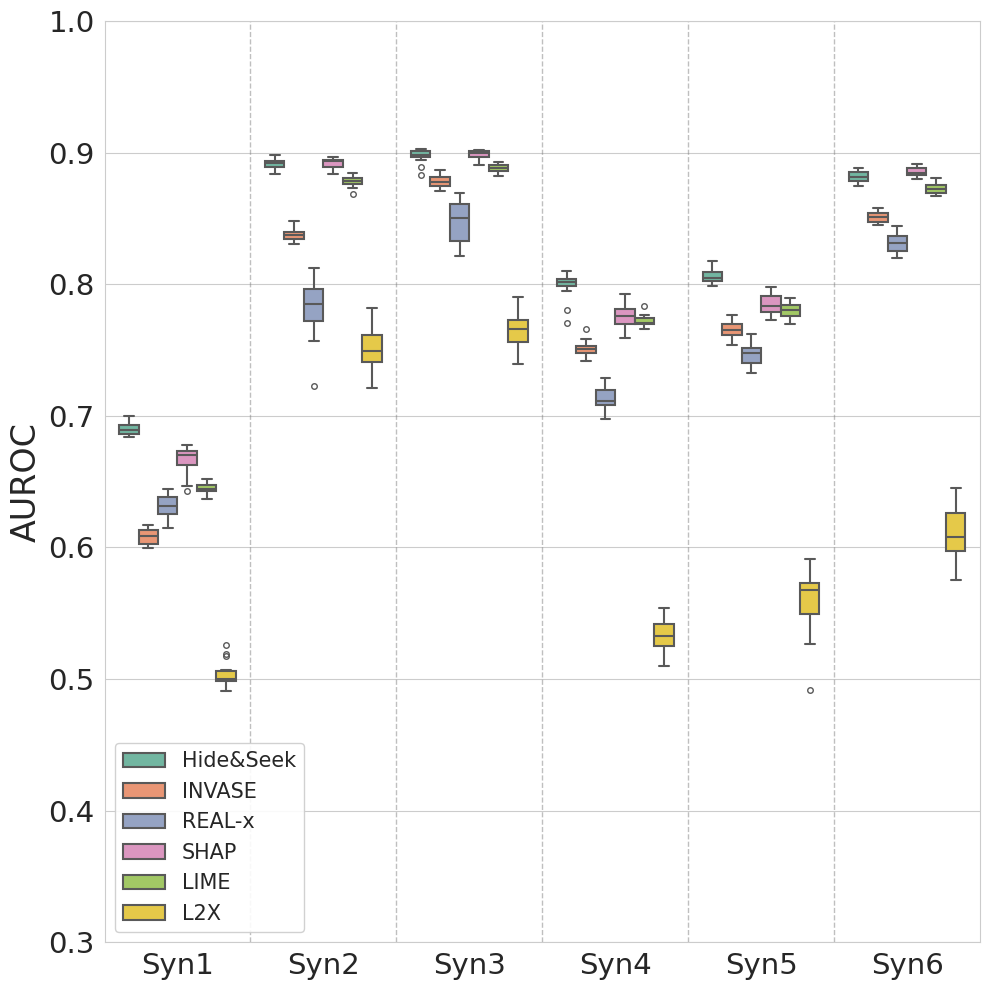

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

save_path = os.path.join(os.path.abspath('..'), 'figures', 'models_roc.pdf') 
save_path = os.path.expanduser(save_path)

def plot_auroc_boxplot(df, font_scale=1.5, figsize=(10, 10), rename_dict=None,
                      save_fig=None):
    """
    Plots a boxplot of ROC AUC scores for each model across all Syn datasets.
    """
    # 1. Setup LaTeX-style font and general parameters
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "DejaVu Serif"], 
        "text.usetex": False, 
        'axes.titlesize': 18 * font_scale,
        'axes.labelsize': 16 * font_scale,
        'xtick.labelsize': 14 * font_scale,
        'ytick.labelsize': 14 * font_scale,
        'legend.fontsize': 10 * font_scale, # Slightly smaller for internal placement
            "pdf.fonttype": 42,
    "ps.fonttype": 42,
    })
    sns.set_style("whitegrid")
    
    # 2. Prepare data and ordering
    model_order = ['Hide&Seek', 'INVASE', 'REAL-x', 'SHAP', 'LIME', 'L2X']
    
    if df['syn'].dtype != object:
        df['syn_label'] = 'Syn' + df['syn'].astype(int).astype(str)
    else:
        df['syn_label'] = df['syn']

    if rename_dict is not None:
        df['model'] = df['model'].replace(rename_dict)
    syn_list = [f'Syn{i}' for i in range(1, 7)]
    plot_df = df[df['model'].isin(model_order)].copy()

    # 3. Define the palette
    palette_colors = sns.color_palette("Set2", n_colors=10)

    # 4. Initialize Plot
    plt.figure(figsize=figsize)
    
    ax = sns.boxplot(
        data=plot_df,
        x='syn_label',
        y='roc_auc',
        hue='model',
        hue_order=model_order,
        palette=palette_colors,
        order=syn_list,
        width=0.8,
        linewidth=1.5,
        fliersize=4
    )

    # 5. Visual Styling
    plt.ylim(0.3,1)
    plt.ylabel('AUROC')
    plt.xlabel('') # Removing 'Syn' label for a cleaner look as Syn1-6 is self-explanatory
    
    for i in range(len(syn_list) - 1):
        plt.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)

    # 6. Internal Legend Placement
    # 'lower left' usually stays clear of the boxes (which sit higher up in the 0.6-0.9 range)
    # frameon=True and framealpha=0.8 ensure the grid doesn't cut through the legend text
    plt.legend(loc='lower left', frameon=True, framealpha=0.9, title=None)

    if save_fig is not None:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# To run it:
plot_auroc_boxplot(temp, rename_dict=rename_dict, save_fig=save_path)

## Mask analysis

In [22]:
mhs = temp.query('model=="Hide&Seek" & seed == 1').reset_index(drop=True)

In [23]:
mhs[['syn','mask']]

,syn,mask
0,1,"[[0.9402691, 0.9318346, 3.761018e-05, 5.114611..."
1,2,"[[1.2826523e-07, 1.1077188e-07, 0.9997398, 0.9..."
2,3,"[[5.834045e-06, 7.711883e-06, 9.760176e-06, 8...."
3,4,"[[0.017206155, 0.017971696, 0.9989197, 0.99826..."
4,5,"[[0.0034492395, 0.00404288, 2.3612097e-06, 2.0..."
5,6,"[[3.1787315e-06, 1.0036571e-06, 0.072900176, 0..."


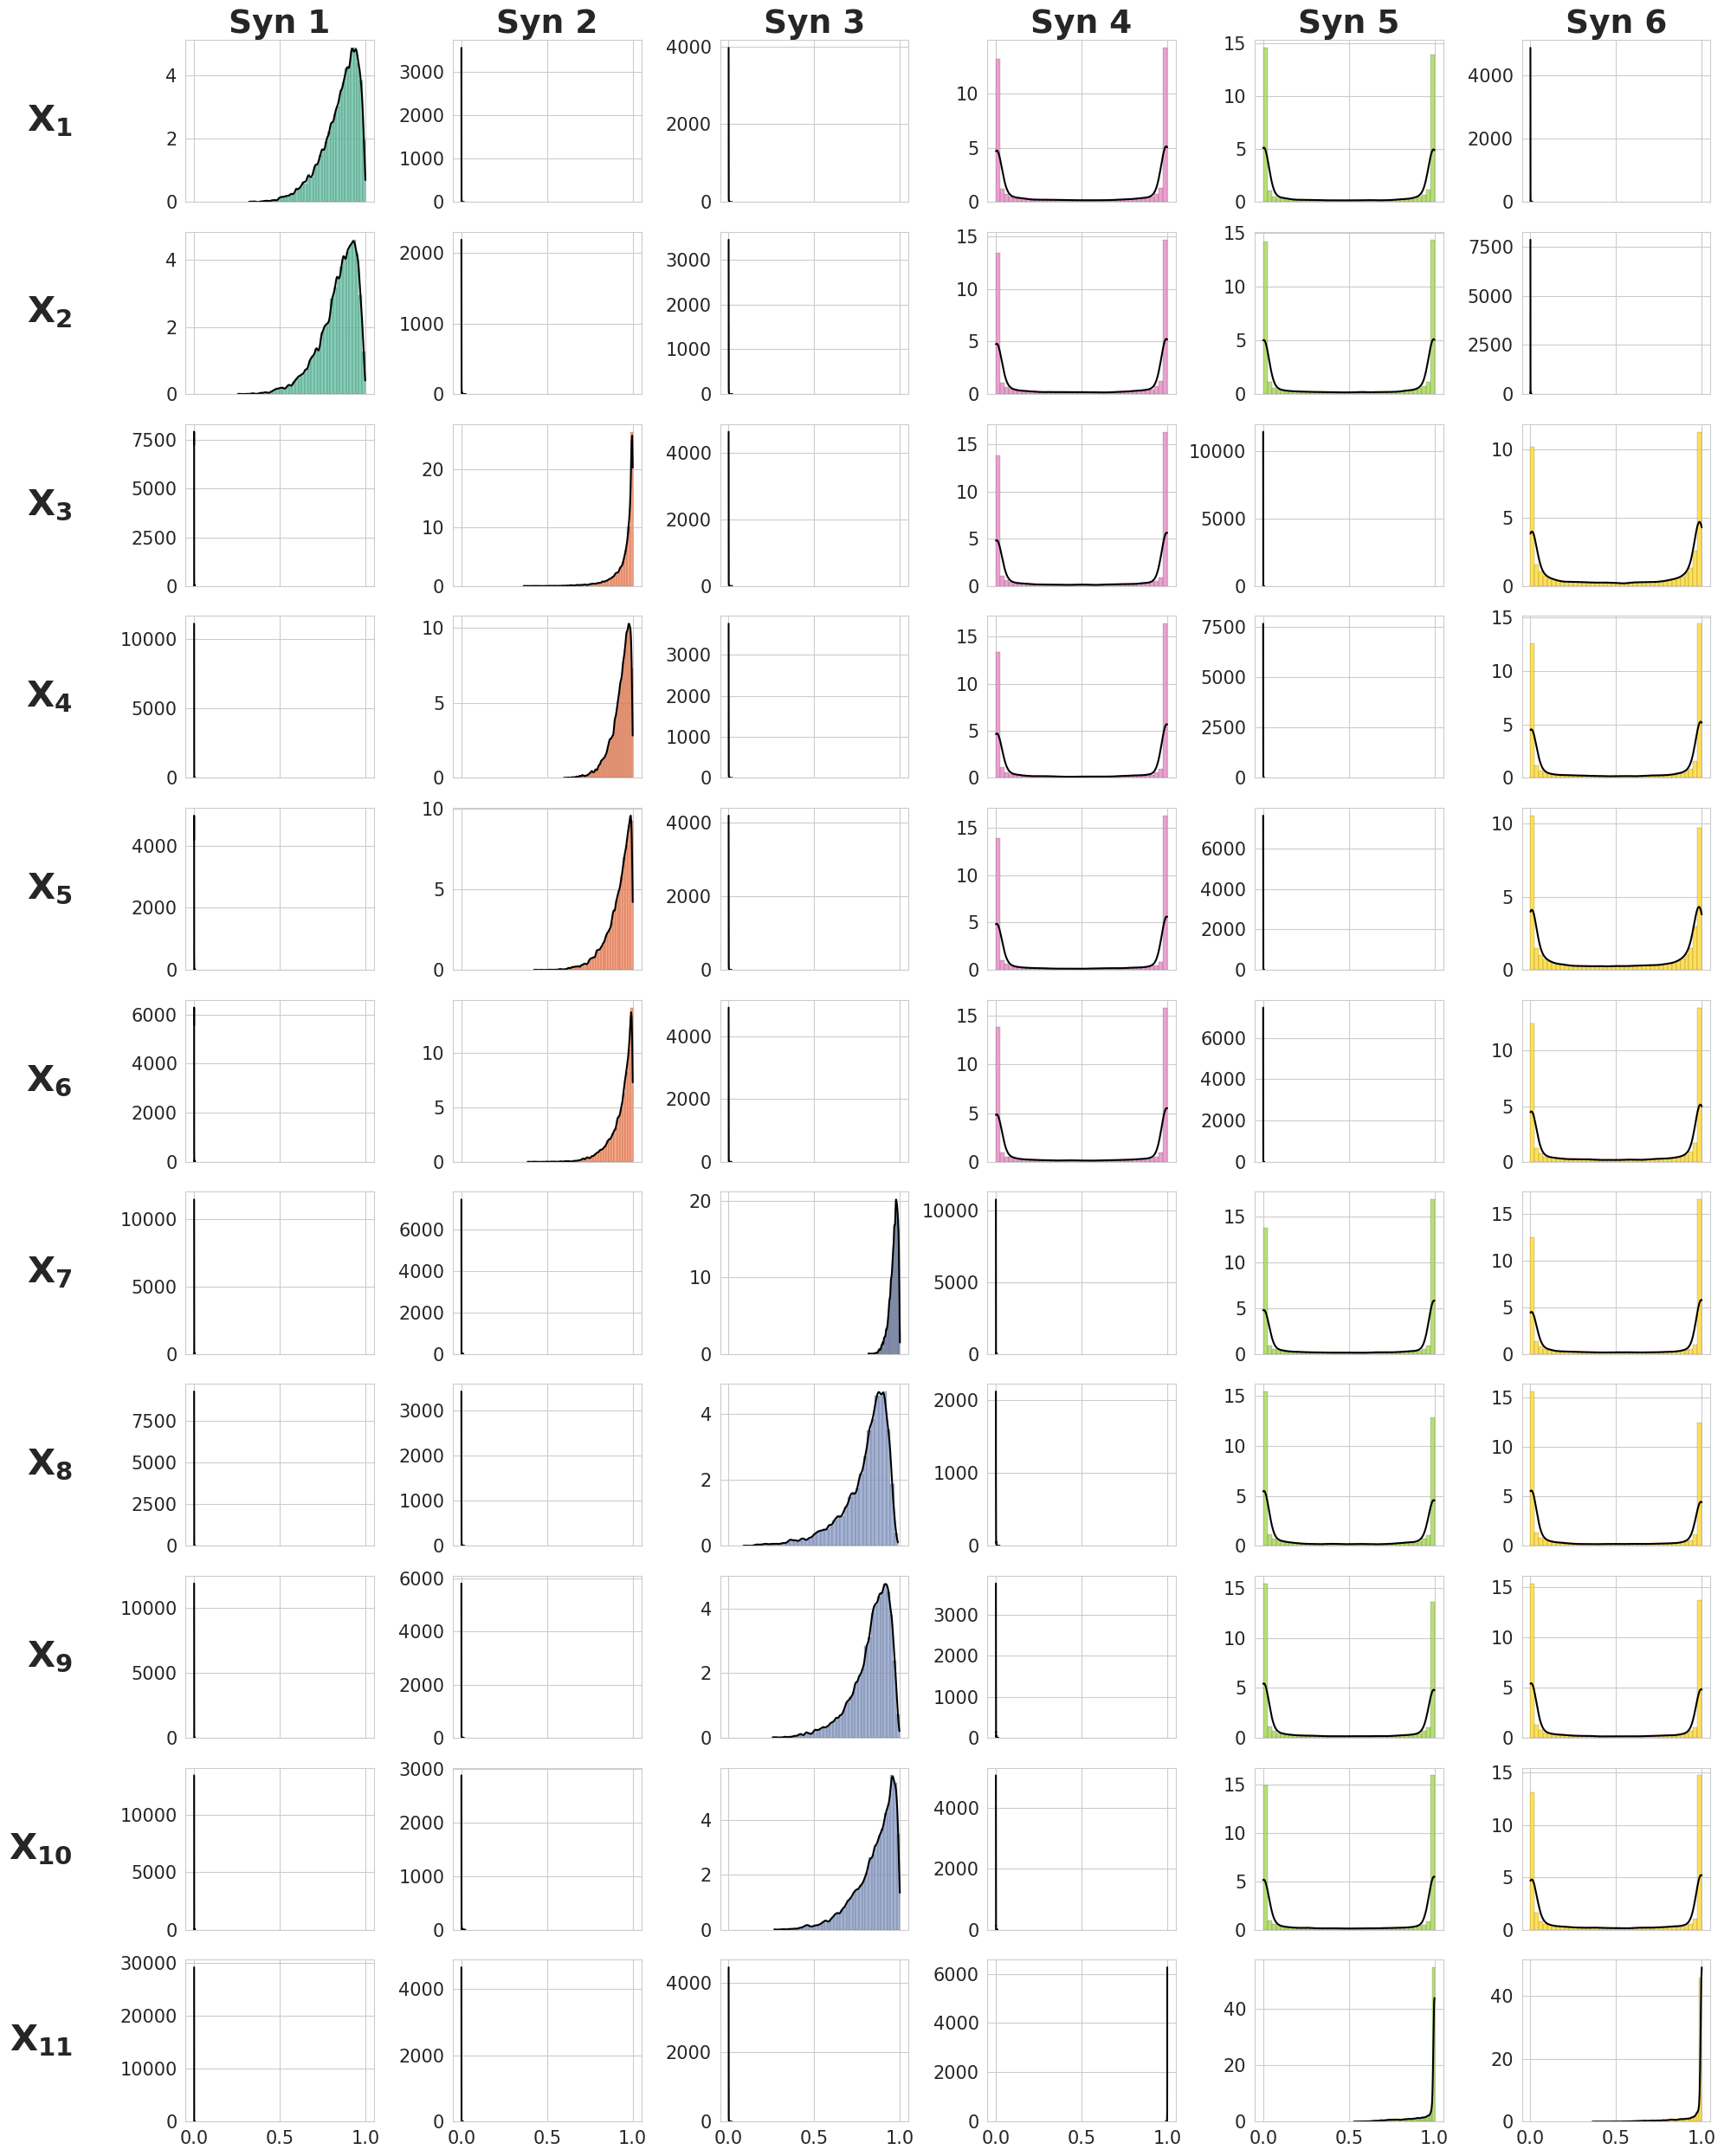

In [28]:
# Run the plot

masks = plot_mask_distributions(mhs, 
                                save_path = os.path.join(os.path.abspath('..'), 'figures', 'mask_distributions.pdf'))

## Boxplots of full TPR, FDR distributions

In [29]:
switch_metrics.groupby(['model','syn']).count()

TPR_mean  FDR_mean  switch_accuracy  run_type  F1  seed  lmbda
model     syn                                                                
Hide&Seek 1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
INVASE    1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
L2X       1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
LASSO     1          20        20               20        20  20    20      0
          2          20        20               20        20  20    20      0
          3          20        20               20        20  20    20      0
          4          20        20               20        20  20    20      0
          5          20        20               20        20  20    20      0
          6          20        20               20        20  20    20      0
LIME      1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
REAL-x    1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
RForest   1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20
SHAP      1          20        20               20        20  20    20     20
          2          20        20               20        20  20    20     20
          3          20        20               20        20  20    20     20
          4          20        20               20        20  20    20     20
          5          20        20               20        20  20    20     20
          6          20        20               20        20  20    20     20

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric_boxplot(df, metric='TPR', syn_levels=None, font_scale=2, use_legend=False,
                       figsize=(10,10),
                       save_path=None):
    if syn_levels is None:
        syn_levels = sorted(df['syn'].unique())

    rename_dict = {
        'FDR_mean': 'FDR',
        'TPR_mean': 'TPR'
    }
    df = df.rename(columns=rename_dict)
    model_order = ['Hide&Seek', 'INVASE', 'REAL-x', 'SHAP', 'LIME', 'L2X']
    syn_list = list(np.unique(df['syn']))
    # Update plotting style
    plt.rcParams.update({
        "font.family": "serif",            # Use serif font family
    "font.serif": ["Computer Modern"], # Computer Modern like in LaTeX
        'axes.titlesize': 18*font_scale,
        'axes.labelsize': 16*font_scale,
        'xtick.labelsize': 14*font_scale,
        'ytick.labelsize': 14*font_scale,
        'legend.fontsize': 14,
            "pdf.fonttype": 42,
    "ps.fonttype": 42,
    })
    sns.set_style("whitegrid")

    # Original palette of 3 colors
    lst = sns.color_palette("Set2", n_colors=10)
    # lst = lst[3:6] + lst[:3] + lst[6:]

    plt.figure(figsize=figsize)
    # ax = sns.boxplot(
    #     data=df,
    #     x='model',
    #     y=metric,
    #     hue='syn',
    #     hue_order=syn_levels,
    #     palette=lst,
    #     order=model_order
    # )

    ax = sns.boxplot(
        data=df,
        x='syn',
        y=metric,
        hue='model',
        hue_order=model_order,
        palette=lst,
        order=syn_list
    )
    ax.legend(title=None) 
    # Add vertical separators
    # n_models = len(model_order)
    n_models = len(syn_list)
    for i in range(n_models - 1):
        plt.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=1)

    plt.title('')
    plt.ylabel(metric)
    plt.xlabel('Syn')
    if use_legend:
        plt.legend(title='Syn', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    if save_path is not None:
        save_path = os.path.expanduser(save_path)
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    plt.show()

/tmp/ipykernel_1715315/2626010603.py:46: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(


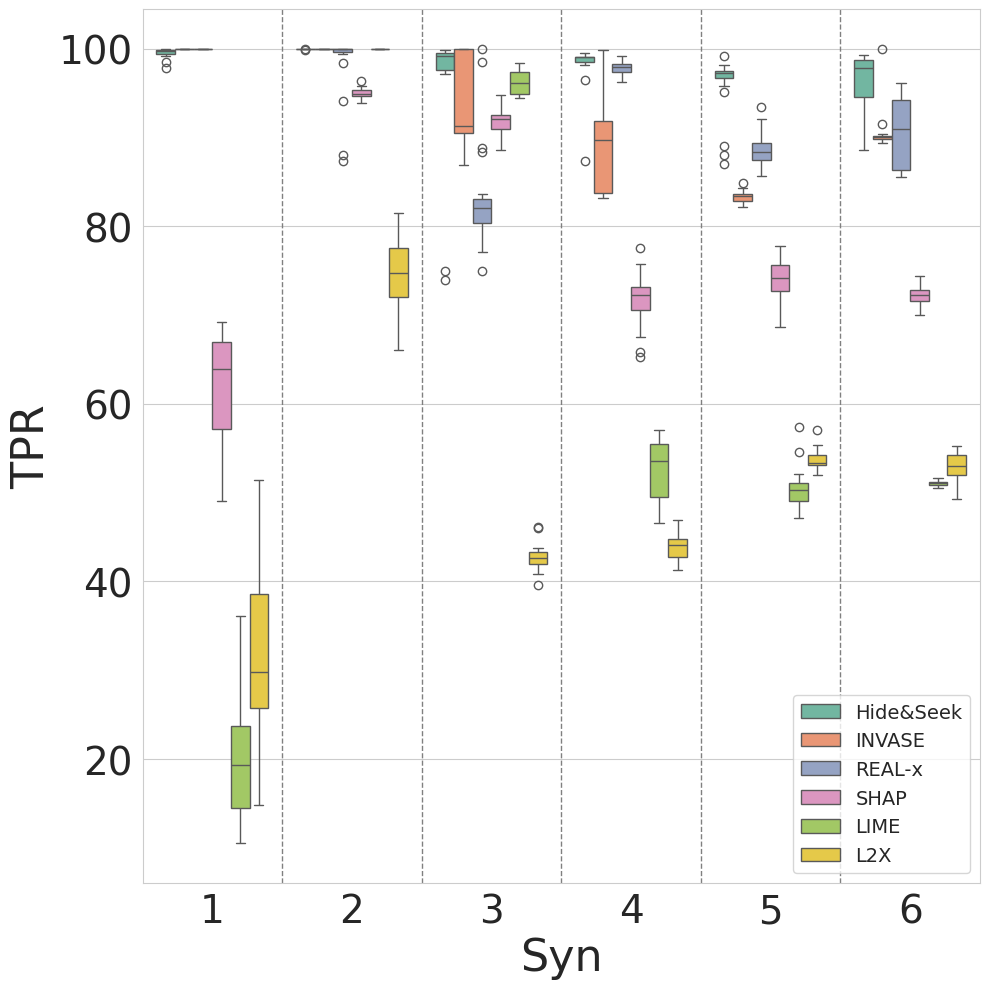

In [32]:
plot_metric_boxplot(df=switch_metrics, metric='TPR', syn_levels=None, use_legend=False,
                   save_path = os.path.join(os.path.abspath('..'), 'figures', 'boxplots_TPR.pdf'))

/tmp/ipykernel_1715315/2626010603.py:46: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(


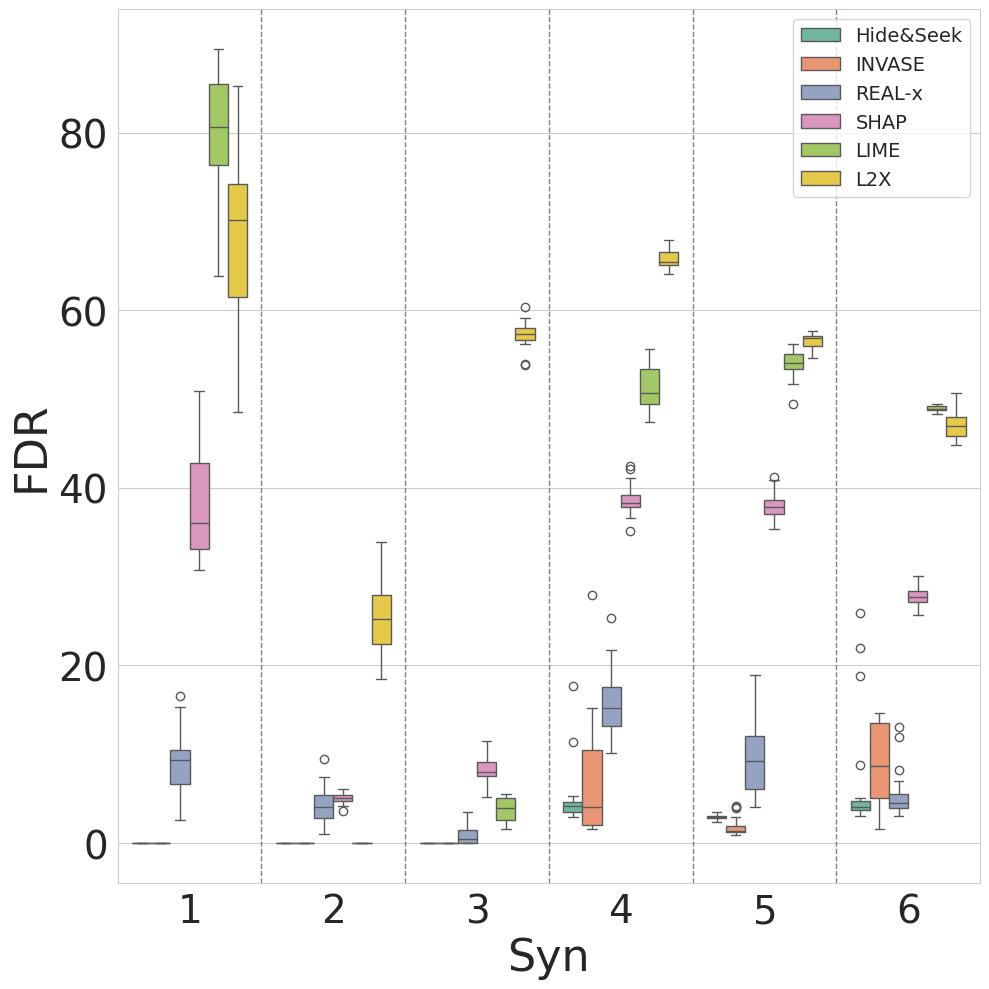

In [33]:
plot_metric_boxplot(df=switch_metrics, metric='FDR', syn_levels=None, use_legend=False,
                   save_path = os.path.join(os.path.abspath('..'), 'figures', 'boxplots_FDR.pdf'))

/tmp/ipykernel_1715315/2626010603.py:46: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(


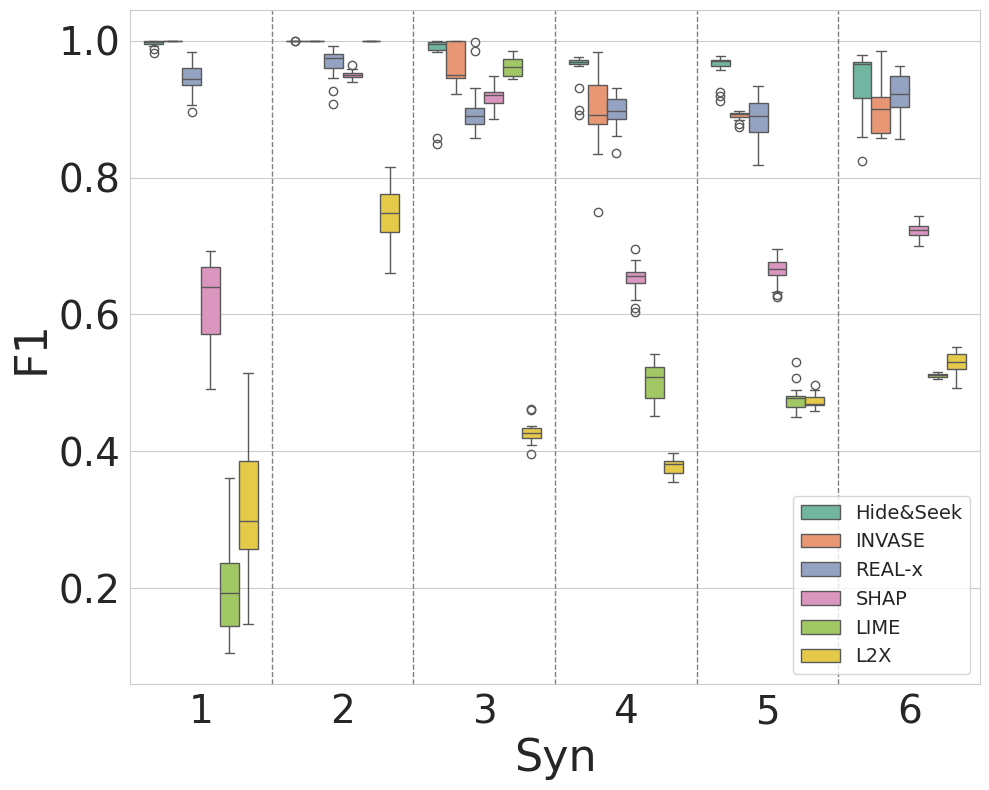

In [34]:
plot_metric_boxplot(df=switch_metrics, metric='F1', syn_levels=None, use_legend=False, figsize=(10,8),
                   font_scale=2,
                   save_path = os.path.join(os.path.abspath('..'), 'figures', 'boxplots_F1.pdf'))

## k = 3,4

In [6]:
switch = load_results_from_pickle(folder='ICML_experiments/synthetic_k3_k4',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig']
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"

temp = switch.copy()
temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp = temp.query('syn != "Syn7"')

In [7]:
def find_switch_accuracy(row):
    switch_accuracy = (row['binary_mask'][:,-1] == row['g_test'][:,-1]).mean()
    return switch_accuracy

In [8]:
# temp.groupby(['model','syn'])['TPR_mean','FDR_mean'].median()

In [9]:
temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)
temp['syn'] = temp.syn.str[-1].astype(int)
cols_to_num = ['TPR_mean', 'FDR_mean', 'f1', 'switch_accuracy', 'seed', 'lmbda']

for col in cols_to_num:
    temp[col] = pd.to_numeric(temp[col])

In [12]:
temp.columns

Index(['syn', 'TPR_mean', 'FDR_mean', 'TPR_std', 'FDR_std', 'f1', 'accuracy',
       'roc_auc', 'pr_auc', 'batch_size', 'save_experiment_data',
       'binary_mask', 'pct_sig', 'g_test', 'mask', 'y_test_pred', 'y_test',
       'epochs', 'lmbda', 'seed', 'model_type', 'num_important_features',
       'lmbda_exponent', 'return_losses_on_val', 'batchnorm_hs', 'num_classes',
       'num_syn_features', 'train_N', 'data_mode', 'scaled_in_tools',
       'weight_classes', 'class_weight_alpha', 'column_names', 'xgb_params',
       'run_type', 'time_run', 'time_end', 'run_id', 'model', 'F1',
       'switch_accuracy'],
      dtype='object')

In [14]:
temp.groupby(['model','num_important_features','syn'])[['TPR_mean','FDR_mean']].count()

TPR_mean  FDR_mean
model num_important_features syn                    
L2X   3                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20
      4                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20
LIME  3                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20
      4                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20
SHAP  3                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20
      4                      1          20        20
                             2          20        20
                             3          20        20
                             4          20        20
                             5          20        20
                             6          20        20

In [26]:
print(temp.query('syn in [4,5]').groupby(['model','num_important_features','syn'])[['TPR_mean','FDR_mean']].median().round(0).astype(int))

                                  TPR_mean  FDR_mean
model num_important_features syn                    
L2X   3                      4          27        65
                             5          35        53
      4                      4          36        65
                             5          45        55
LIME  3                      4          30        50
                             5          30        50
      4                      4          40        50
                             5          41        51
SHAP  3                      4          46        34
                             5          48        32
      4                      4          60        35
                             5          63        34
